In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../../scripts')

In [3]:
from helpers import _normalize_counts, safe_log2_fold_change, compute_correlations, subsample_adata

In [ ]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
DATA_ROOT = os.environ.get("DATA_ROOT", ".")
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

from cellina import CellinaModel
from utils import set_seed
from train_loo import preprocess_crc

In [6]:
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.dpi'] = 50


In [7]:
import cellina
cellina.__version__

'0.99.1'

# Get dataset

In [8]:
set_seed(0)

In [9]:
slide_id = 'crc_210'

In [12]:
data_path = os.path.join(DATA_ROOT, f"datasets/crc/raw_zenodo/{slide_id}.h5ad")
adata = sc.read(data_path)
adata.obs_names_make_unique()

In [13]:
adata = preprocess_crc(adata)

/data/ddimitrov/repos/cellina-reproducibility/notebooks/application/../../scripts/train_loo.py:175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


In [14]:
adata

AnnData object with n_obs × n_vars = 552241 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [15]:
labels_key = 'coarse_type'
domains_key = 'typ_clean'
batch_key = 'sid'

In [16]:
fig_save_path = "../../figures/application"

... storing 'typ_clean' as categorical


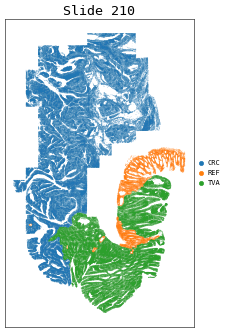

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))  # width x height in inches

sc.pl.spatial(
    adata,
    color=domains_key,
    ax=ax,
    spot_size=100,
    title=f"Slide 210",
    show=False,
)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}slide.png", bbox_inches='tight')

## Data splits

In [ ]:
split = "random"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_ct = "Fibroblast"
    is_tumor_region  = adata.obs[domains_key].str.contains("CRC", regex=True)
    is_holdout_ct = adata.obs[labels_key] == holdout_ct

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [ ]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [ ]:
validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

from cellina._spatial_utils import spatial_neighbors, compute_spatial_features

step_size_px = 0.12028
spatial_neighbors(adata, bandwidth=100 / step_size_px, max_neighbours=200, standardize=False, test_indices=test_idx)
compute_spatial_features(adata)

adata.X = adata.layers['counts'].copy()

# Train

In [ ]:
model_base_path = f"./{slide_id}"

In [ ]:
from scvi.train._callbacks import SaveCheckpoint, EarlyStopping

model_args = {
    'adata': adata,
    'n_latent': 64,
    'n_layers': 3,
    'use_observed_lib_size': True,
    'condition_on_intrinsic': False,
    'gene_likelihood': 'nb',
    'classifier_lambda': 1.,
    'discriminator_lambda': 1.,
    }
train_args = {'max_epochs': 100,
              'batch_size': 4096,
              'check_val_every_n_epoch': 1,
              'early_stopping': True,
              'devices': [0],
              'datasplitter_kwargs': {
                  "external_indexing": [train_idx, val_idx, test_idx],
                  },
              'enable_checkpointing':True,
              'callbacks': [
                  SaveCheckpoint(
                      monitor='vae_loss_validation',
                      dirpath=f"{model_base_path}",
                      load_best_on_end=True,
                      ),
                  EarlyStopping(
                      monitor="vae_loss_validation",
                      patience=5,
                      mode="min",
                    ),
                ],
    }

plan_kwargs = {
    'lr': 1e-3,
    'normalize_losses': True
    }

In [ ]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

In [ ]:
model = CellinaModel(
    **model_args, 
)
model.train(**train_args, plan_kwargs=plan_kwargs)

# Inference and clustering

In [ ]:
checkpoint_name = os.listdir(f"{model_base_path}")[0]
model = CellinaModel.load(
    f"{model_base_path}/{checkpoint_name}",
    adata=adata,
)

In [ ]:
adata.obsm['cellina_basal'] = model.get_latent_representation(adata=adata, latent_key='z', batch_size=4096)
adata.obsm['cellina_spatial'] = model.get_latent_representation(adata=adata, latent_key='s', batch_size=4096)
# adata.obsm['cellina_latent'] = model.get_latent_representation(adata=adata, batch_size=4096)

### Latent visualization

In [ ]:
adata_sub = subsample_adata(adata, fraction=0.5)


In [ ]:
sc.pp.neighbors(adata_sub, use_rep='cellina_basal')
sc.tl.umap(adata_sub)

In [ ]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/crc_210_umap_basal_ct.png", bbox_inches='tight')

In [ ]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_basal_niche.png", bbox_inches='tight')

In [ ]:
sc.pp.neighbors(adata_sub, use_rep='cellina_spatial')
sc.tl.umap(adata_sub)

In [ ]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, show=False, title="cellina spatial (s)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_ct.png", bbox_inches='tight')

In [ ]:
palette = {
    # Control
    'REF': '#E69F00',

    # CRC
    'CRC': "#0075D5",

    # TVA
    'TVA': "#00B221",
}

In [ ]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, show=False, title="cellina spatial (s)", palette=palette)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_niche.png", bbox_inches='tight')

## Hotspot clusters

In [ ]:
import pandas as pd
import decoupler as dc
import hotspot

from plotting import plot_custom_umap

In [ ]:
adata_crc = adata[adata.obs[domains_key].str.contains('CRC')].copy()

In [ ]:
set_seed(0)  # ensure reproducible hotspot KNN and module detection

In [ ]:
hs = hotspot.Hotspot(
    adata_crc,
    layer_key="counts",
    model='danb',
    latent_obsm_key="cellina_spatial",
    umi_counts_obs_key="nCount_RNA"
)

hs.create_knn_graph(
    weighted_graph=False, n_neighbors=30,
)

In [ ]:
hs_results = hs.compute_autocorrelations(jobs=24)

In [ ]:
# Select the genes with significant lineage autocorrelation
top_k = 1200
hs_genes = hs_results.loc[hs_results.FDR < 0.05].head(top_k).index

In [ ]:
# Compute pair-wise local correlations between these genes
load_lcz = False
base_dir = f'../results/analysis/{slide_id}'
lcz_path = f'{base_dir}/hotspot_lcz_crc.csv'

if load_lcz:
    lcz = pd.read_csv(lcz_path, index_col=0)
    hs.local_correlation_z = lcz
else:
    lcz = hs.compute_local_correlations(hs_genes, jobs=24)
    os.makedirs(base_dir, exist_ok=True)
    lcz.to_csv(lcz_path)

In [ ]:
modules = hs.create_modules(min_gene_threshold=100, core_only=True, fdr_threshold=0.05)

In [ ]:
module_scores = hs.calculate_module_scores()

module_scores.head()

In [ ]:
module_cols = []
for c in module_scores.columns:
    key = f"Module {c}"
    adata_crc.obs[key] = module_scores[c]
    module_cols.append(key)

In [ ]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=module_cols,frameon=False, vmin=-1, vmax=1, wspace=0.2
)

In [ ]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=['typ_clean', 'ist', 'jst'], frameon=False, vmin=-1, vmax=1, wspace=0.2
)

In [ ]:
module_scores_epi = module_scores.loc[adata_crc.obs_names]

In [ ]:
adata_crc.obsm['module_scores'] = module_scores_epi.values

In [ ]:
top_modules = module_scores.idxmax(axis=1)

# Add to adata.obs
adata_crc.obs["top_module"] = top_modules.astype(str)
adata_crc.obs["top_module"] = adata_crc.obs["top_module"].astype("category")

In [ ]:
# Plot
sc.pl.spatial(
    adata_crc,
    color=["top_module", "ist", "typ"],
    palette=None,
    spot_size=50,
    show=True
)

In [ ]:
# top module to f{CRC{}}
adata_crc.obs['microenvironment'] = adata_crc.obs['top_module'].apply(lambda x: f"CRC{x}")

In [ ]:
adata_crc.obs['microenvironment'].value_counts()

### Remap

In [ ]:
typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata_sub.obs_names)  # NaN for non-CRC cells

adata_sub.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata_sub.obs['typ'].astype(str))
)

typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata.obs_names)  # NaN for non-CRC cells
adata.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata.obs['typ'].astype(str))
)
    

In [ ]:
adata.obs['microenvironment'].value_counts()

In [ ]:
# Plot how many cells of each microenvironment are present in each cell type
celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=celltype_microenv_counts, x=labels_key, y='count', hue='microenvironment')
plt.xticks(rotation=45)
plt.title("Cell type counts across microenvironments")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Counterfactuals - CRC_global vs. CRC_microenv

In [ ]:
celltypes = ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'T_cell']
microenvironments = [m for m in adata.obs['microenvironment'].unique() if 'CRC' in m]
results = {k: adata[adata.obs[labels_key] == k] for k in celltypes}

In [ ]:
print(microenvironments)

In [ ]:
for ct in tqdm(celltypes, desc=f"Cell types"):
    # Control set is same - only target changes (either crc_all or microenv labels)
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    is_celltype = adata.obs[labels_key].astype(str) == ct
    
    mask_control = ~is_tumor_region & is_celltype
    # mask_control = adata.obs[domains_key].astype(str).str.contains('REF', regex=True) & is_celltype # NOTE: changed from ~CRC to REF
    
    idx_control = np.where(mask_control.values)[0]

    # 1. Compute counterfactuals for global crc
    mask_target = is_tumor_region
    #mask_target = is_tumor_region & is_celltype
    idx_target = np.where(mask_target.values)[0]
    args = {
                "adata": adata,
                "indices": idx_control,
                "neighbour_indices": idx_target,
                "batch_size": 4096,
                "seed": 0,
            }
    results[ct].obsm['recon_x'] = model.get_normalized_expression(adata=results[ct], batch_size=4096, library_size=1e4)
    results[ct].uns[f'counterfactual_x_global'] = model.get_counterfactual_expression(**args, library_size=1e4)
    results[ct].uns[f'counterfactual_latents_global'] = model.get_counterfactual_latents(**args, latent_key='shifted')

    # 2. Loop over microenvironments
    for microenv in tqdm(microenvironments, desc=f"Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        mask_target = is_in_microenv
        #mask_target = is_in_microenv & is_celltype
        idx_target = np.where(mask_target.values)[0]
        args["neighbour_indices"] = idx_target
        results[ct].uns[f'counterfactual_x_{microenv}'] = model.get_counterfactual_expression(**args, library_size=1e4)
        results[ct].uns[f'counterfactual_latents_{microenv}'] = model.get_counterfactual_latents(**args, latent_key='shifted')

In [ ]:
# _normalize_counts, safe_log2_fold_change, compute_correlations imported from helpers (cell 2)


In [ ]:
summary = []
deg = 200

for ct, dataset in tqdm(results.items(), desc="Computing correlations"):
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    mask_control = ~dataset.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    # mask_control = dataset.obs[domains_key].astype(str).str.contains('REF', regex=True) # NOTE: change from ~CRC to REF?

    control = dataset.layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    is_ct = dataset.obs[labels_key].astype(str) == ct
    #mask_target = is_tumor_region & is_ct
    mask_target = is_tumor_region
    target = adata.layers['counts'].todense()[mask_target]
    target = np.asarray(target)

    counterfactual = dataset.uns['counterfactual_x_global']
    pear_global, spear_global = compute_correlations(control, target, counterfactual, deg=deg)

    summary.append({
        "cell_type": ct,
        "label": "CRC_global",
        "pearson": np.round(pear_global, 4),
        "spearman": np.round(spear_global, 4)
    })

    for microenv in tqdm(microenvironments, desc="Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        
        #mask_target = is_in_microenv & is_ct
        mask_target = is_in_microenv
        target = adata.layers['counts'].todense()[mask_target]

        target = np.asarray(target)
        counterfactual = dataset.uns[f'counterfactual_x_{microenv}']
        pear_microenv, spear_microenv = compute_correlations(control, target, counterfactual, deg=deg)
        summary.append({
            "cell_type": ct,
            "label": microenv,
            "pearson": np.round(pear_microenv, 4),
            "spearman": np.round(spear_microenv, 4)
        })

In [ ]:
summary_df = pd.DataFrame(summary)

In [ ]:
print(summary_df)

In [ ]:
# Save df
summary_df.to_csv(f"../../results/microenvironments_{slide_id}.csv", index=False)

## Save outputs

In [ ]:
# ── Save Part 1 outputs ────────────────────────────────────────────────────
import pickle, os

os.makedirs("output", exist_ok=True)

# Save annotated AnnData (includes obsm latents + obs microenvironment)
adata.write_h5ad("output/adata_with_microenv.h5ad")
print("Saved adata to output/adata_with_microenv.h5ad")

# Save Hotspot object (modules, results, etc.)
with open("output/hotspot.pkl", "wb") as _f:
    pickle.dump(hs, _f)
print("Saved hotspot to output/hotspot.pkl")

# Save per-cell-type results dict (AnnData objects with .uns counterfactuals)
with open("output/results.pkl", "wb") as _f:
    pickle.dump(results, _f)
print("Saved results dict to output/results.pkl")

print(f"Model checkpoint saved at: {model_base_path}")
